In [3]:
# ============================================================
# TP2 - Mi primera red neuronal
# Bloque 1: imports y configuración
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Reproducibilidad
np.random.seed(42)

# Carpeta para outputs
RESULTS_DIR = Path(r"C:\Users\agust\OneDrive\Desktop notebook casa\Bioinfo\tp2y3-minired-aguselara1-tech-main\results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Results dir:", RESULTS_DIR.resolve())

Results dir: C:\Users\agust\OneDrive\Desktop notebook casa\Bioinfo\tp2y3-minired-aguselara1-tech-main\results


In [4]:
# ============================================================
# Bloque 2: función objetivo
# ============================================================

def target_function(x):
    """
    Función objetivo por tramos del TP.
    Acepta escalar o array de numpy.
    """
    x = np.asarray(x)
    
    y = np.zeros_like(x, dtype=float)
    y[(x >= -0.33) & (x < 0.33)] = 1.0
    y[(x >= 0.33) & (x < 1.01)] = 0.5
    
    return y

In [5]:
# ============================================================
# Bloque 3: batch de entrada y salida verdadera
# ============================================================

x_values = np.arange(-1.0, 1.01, 0.1)   # incluye 1.0
y_values = target_function(x_values)

# Formato de red: batch_size x input_features
X = x_values.reshape(-1, 1)     # shape: (21, 1)
Y = y_values.reshape(-1, 1)     # shape: (21, 1)

print("x_values shape:", x_values.shape)
print("y_values shape:", y_values.shape)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nPrimeros 5 valores de X:")
print(X[:5])

print("\nPrimeros 5 valores de Y:")
print(Y[:5])

x_values shape: (21,)
y_values shape: (21,)
X shape: (21, 1)
Y shape: (21, 1)

Primeros 5 valores de X:
[[-1. ]
 [-0.9]
 [-0.8]
 [-0.7]
 [-0.6]]

Primeros 5 valores de Y:
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


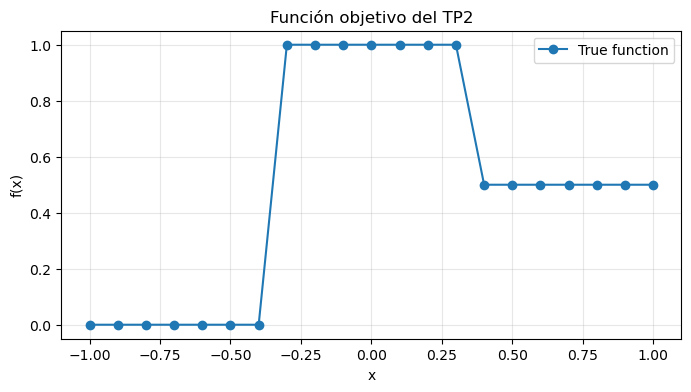

In [6]:
# ============================================================
# Bloque 4: gráfico de la función verdadera
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(x_values, y_values, marker="o", label="True function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función objetivo del TP2")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(RESULTS_DIR / "tp2_true_function.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ============================================================
# Bloque 5: inicialización de la red
# ============================================================

def initialize_network(input_size, hidden_sizes, output_size):
    """
    Inicializa weights y biases de una red neuronal.
    
    Parámetros
    ----------
    input_size : int
        Número de inputs de la red.
    hidden_sizes : list[int]
        Número de neuronas en cada capa oculta.
    output_size : int
        Número de outputs de la red.
    
    Retorna
    -------
    network : list[tuple[np.ndarray, np.ndarray]]
        Lista de tuplas (weights, biases), una por capa.
    """
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    print("Layer sizes:", layer_sizes)
    
    network = []
    
    for i in range(len(layer_sizes) - 1):
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        biases = np.zeros(layer_sizes[i + 1])
        network.append((weights, biases))
    
    return network

In [9]:
# ============================================================
# Bloque 6: inspección de la red
# ============================================================

def inspect_network(network):
    """
    Imprime la forma de weights y biases de cada capa.
    """
    total_weights = 0
    total_biases = 0
    
    print("=== Inspección de la red ===")
    
    for i, (weights, biases) in enumerate(network, start=1):
        n_weights = weights.size
        n_biases = biases.size
        
        total_weights += n_weights
        total_biases += n_biases
        
        print(f"\nCapa {i}")
        print(f"  weights shape: {weights.shape}")
        print(f"  biases shape : {biases.shape}")
        print(f"  cantidad de weights: {n_weights}")
        print(f"  cantidad de biases : {n_biases}")
        print(f"  weights:\n{weights}")
        print(f"  biases:\n{biases}")
    
    print("\n=== Totales ===")
    print("Total de weights:", total_weights)
    print("Total de biases :", total_biases)

In [30]:
# ============================================================
# Bloque 7: probar una arquitectura
# ============================================================

input_size = 1
hidden_sizes = [3, 3, 3]
output_size = 1

network = initialize_network(input_size, hidden_sizes, output_size)
inspect_network(network)

Layer sizes: [1, 3, 3, 3, 1]
=== Inspección de la red ===

Capa 1
  weights shape: (3, 1)
  biases shape : (3,)
  cantidad de weights: 3
  cantidad de biases : 3
  weights:
[[-0.04657298]
 [ 0.02419623]
 [-0.19132802]]
  biases:
[0. 0. 0.]

Capa 2
  weights shape: (3, 3)
  biases shape : (3,)
  cantidad de weights: 9
  cantidad de biases : 3
  weights:
[[-0.17249178 -0.05622875 -0.10128311]
 [ 0.03142473 -0.09080241 -0.14123037]
 [ 0.14656488 -0.02257763  0.00675282]]
  biases:
[0. 0. 0.]

Capa 3
  weights shape: (3, 3)
  biases shape : (3,)
  cantidad de weights: 9
  cantidad de biases : 3
  weights:
[[-0.14247482 -0.05443827  0.01109226]
 [-0.11509936  0.0375698  -0.06006387]
 [-0.02916937 -0.06017066  0.18522782]]
  biases:
[0. 0. 0.]

Capa 4
  weights shape: (1, 3)
  biases shape : (1,)
  cantidad de weights: 3
  cantidad de biases : 1
  weights:
[[-0.00134972 -0.10577109  0.08225449]]
  biases:
[0.]

=== Totales ===
Total de weights: 24
Total de biases : 10


In [31]:
# ============================================================
# Bloque 8: función de activación
# ============================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [32]:
# ============================================================
# Bloque 9: forward pass para una capa
# ============================================================

def forward_layer_batch(inputs, weights, biases):
    """
    Forward pass de una capa para un batch de inputs.
    
    Parámetros
    ----------
    inputs : np.ndarray
        Shape: (batch_size, input_features)
    weights : np.ndarray
        Shape: (n_neurons, input_features)
    biases : np.ndarray
        Shape: (n_neurons,)
    
    Retorna
    -------
    outputs : np.ndarray
        Shape: (batch_size, n_neurons)
    """
    z = np.dot(inputs, weights.T) + biases
    return sigmoid(z)

In [33]:
# ============================================================
# Bloque 10: forward pass para toda la red
# ============================================================

def forward_network_batch(inputs, network):
    """
    Forward pass completo para una red y un batch.
    
    Parámetros
    ----------
    inputs : np.ndarray
        Shape: (batch_size, input_features)
    network : list of tuples
        Lista de (weights, biases)
    
    Retorna
    -------
    activations : list
        Lista con las activaciones de cada capa, incluyendo input y output final.
    """
    activations = [inputs]
    
    for weights, biases in network:
        inputs = forward_layer_batch(inputs, weights, biases)
        activations.append(inputs)
    
    return activations

In [34]:
# ============================================================
# Bloque 11: forward pass con la red aleatoria
# ============================================================

activations = forward_network_batch(X, network)

print("Cantidad de niveles guardados en activations:", len(activations))

for i, a in enumerate(activations):
    print(f"\nActivación {i}: shape = {a.shape}")
    print(a[:5])  # primeras 5 filas

Cantidad de niveles guardados en activations: 5

Activación 0: shape = (21, 1)
[[-1. ]
 [-0.9]
 [-0.8]
 [-0.7]
 [-0.6]]

Activación 1: shape = (21, 3)
[[0.51164114 0.49395124 0.54768663]
 [0.51047739 0.49455606 0.54294275]
 [0.50931352 0.49516091 0.53819107]
 [0.50814955 0.49576576 0.53343245]
 [0.50698549 0.49637063 0.52866773]]

Activación 2: shape = (21, 3)
[[0.45722989 0.47349393 0.51687729]
 [0.45739051 0.47363815 0.51682328]
 [0.45755134 0.47378265 0.51676926]
 [0.45771236 0.47392739 0.51671523]
 [0.45787354 0.47407235 0.51666118]]

Activación 3: shape = (21, 3)
[[0.47871622 0.48353509 0.51347486]
 [0.4787084  0.48353264 0.51346902]
 [0.47870057 0.48353018 0.51346318]
 [0.47869273 0.48352772 0.51345733]
 [0.47868488 0.48352526 0.51345148]]

Activación 4: shape = (21, 1)
[[0.49761138]
 [0.49761133]
 [0.49761127]
 [0.49761122]
 [0.49761117]]


In [35]:
# ============================================================
# Bloque 12: predicción final de la red random
# ============================================================

y_pred_random = activations[-1]

print("Shape de la predicción final:", y_pred_random.shape)
print("\nPrimeras 10 predicciones:")
print(y_pred_random[:10])

Shape de la predicción final: (21, 1)

Primeras 10 predicciones:
[[0.49761138]
 [0.49761133]
 [0.49761127]
 [0.49761122]
 [0.49761117]
 [0.49761112]
 [0.49761106]
 [0.49761101]
 [0.49761096]
 [0.49761091]]


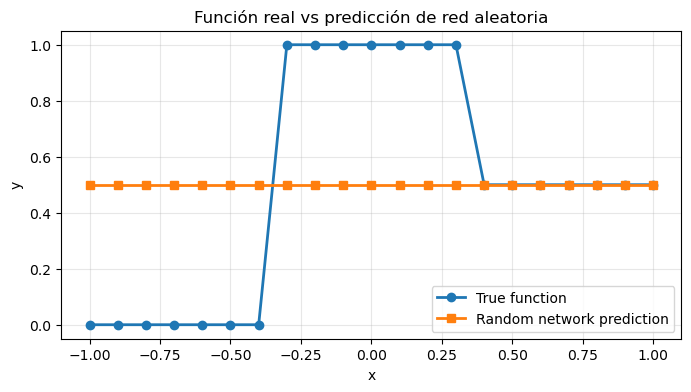

In [36]:
# ============================================================
# Bloque 13: gráfico de función real vs predicción random
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(x_values, y_values, marker="o", linewidth=2, label="True function")
plt.plot(x_values, y_pred_random.flatten(), marker="s", linewidth=2, label="Random network prediction")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Función real vs predicción de red aleatoria")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(RESULTS_DIR / "tp2_true_vs_random_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
La red aleatoria produce una función suave determinada por los pesos iniciales, pero no reproduce adecuadamente la función objetivo. Esto muestra que la arquitectura 
por sí sola no alcanza; es necesario entrenar la red para ajustar los parámetros y aproximar la función deseada.
los pesos iniciales son chicos,
los bias arrancan en cero,
la sigmoide aplasta todo hacia valores cercanos a 0.5,
y como todavía no hubo entrenamiento, la red no tiene por qué parecerse a la función objetivo.

In [52]:
# ============================================================
# Bloque 14: derivada de activación y función de pérdida
# ============================================================

def sigmoid_derivative_from_activation(a):
    return a * (1 - a)

def rmse_loss(y_pred, y_true):
    """
    Root Mean Squared Error
    """
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

In [53]:
# ============================================================
# Bloque 15: backward pass para una capa
# ============================================================

def backward_layer_batch(inputs, weights, biases, d_loss, activation_derivative):
    """
    Backward pass para una capa con batch.

    Parámetros
    ----------
    inputs : np.ndarray
        Entrada a la capa, shape (batch_size, input_features)
    weights : np.ndarray
        Pesos de la capa, shape (n_neurons, input_features)
    biases : np.ndarray
        Biases de la capa, shape (n_neurons,)
    d_loss : np.ndarray
        Gradiente de la loss respecto de la salida de esta capa,
        shape (batch_size, n_neurons)
    activation_derivative : np.ndarray
        Derivada de la activación evaluada en la salida de la capa,
        shape (batch_size, n_neurons)

    Retorna
    -------
    d_weights : np.ndarray
    d_biases : np.ndarray
    d_inputs : np.ndarray
    """
    # Gradiente respecto de la activación pre-update
    d_activation = d_loss * activation_derivative

    # Gradientes de weights y biases
    d_weights = np.dot(d_activation.T, inputs) / len(inputs)
    d_biases = np.mean(d_activation, axis=0)

    # Gradiente que se propaga hacia la capa anterior
    d_inputs = np.dot(d_activation, weights)

    return d_weights, d_biases, d_inputs

In [54]:
# ============================================================
# Bloque 16: backward pass para toda la red
# ============================================================

def backward_network_batch(activations, network, y_true, learning_rate):
    """
    Backward completo sobre toda la red y actualización de parámetros.

    Parámetros
    ----------
    activations : list
        Lista de activaciones del forward pass
    network : list
        Lista de (weights, biases)
    y_true : np.ndarray
        Valores reales, shape (batch_size, output_neurons)
    learning_rate : float
        Tasa de aprendizaje

    Retorna
    -------
    loss : float
        Loss del batch
    """
    y_pred = activations[-1]
    loss = rmse_loss(y_pred, y_true)

    # Gradiente de RMSE respecto de la salida final
    d_loss = (y_pred - y_true) / (len(y_true) * loss + 1e-15)

    # Recorremos la red hacia atrás
    for i in reversed(range(len(network))):
        weights, biases = network[i]
        inputs = activations[i]
        outputs = activations[i + 1]

        activation_derivative = sigmoid_derivative_from_activation(activations[i + 1])

        d_weights, d_biases, d_loss = backward_layer_batch(
            inputs, weights, biases, d_loss, activation_derivative
        )

        # Update de parámetros
        network[i] = (
            weights - learning_rate * d_weights,
            biases - learning_rate * d_biases
        )

    return loss

In [94]:
# ============================================================
# Bloque 17: training loop
# ============================================================

def train_network(
    X,
    Y,
    input_size,
    hidden_sizes,
    output_size,
    epochs=20000,
    initial_lr=1.0,
    lr_decay=0.01,
    seed=42,
    verbose_every=200
):
    """
    Inicializa y entrena una red neuronal.

    Retorna
    -------
    network : red entrenada
    losses : lista de losses por época
    lr_history : lista de learning rates por época
    """
    np.random.seed(seed)
    network = initialize_network(input_size, hidden_sizes, output_size)

    losses = []
    lr_history = []

    for epoch in range(1, epochs + 1):
        lr = initial_lr / (1 + lr_decay * (epoch - 1))
        activations = forward_network_batch(X, network)
        loss = backward_network_batch(activations, network, Y, lr)

        losses.append(loss)
        lr_history.append(lr)

        if verbose_every is not None and (epoch == 1 or epoch % verbose_every == 0 or epoch == epochs):
            print(f"Epoch {epoch:4d} | LR = {lr:.5f} | Loss = {loss:.6f}")

    return network, losses, lr_history

In [90]:
# ============================================================
# Bloque 18: primera corrida de entrenamiento
# ============================================================

input_size = 1
hidden_sizes = [1, 3, 1]
output_size = 1

trained_network, losses, lr_history = train_network(
    X=X,
    Y=Y,
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    epochs=200,
    initial_lr=0.1,
    lr_decay=0.01,
    seed=42,
    verbose_every=20
)

Layer sizes: [1, 1, 3, 1, 1]
Epoch    1 | LR = 0.10000 | Loss = 0.408368
Epoch   20 | LR = 0.08403 | Loss = 0.408364
Epoch   40 | LR = 0.07194 | Loss = 0.408360
Epoch   60 | LR = 0.06289 | Loss = 0.408358
Epoch   80 | LR = 0.05587 | Loss = 0.408355
Epoch  100 | LR = 0.05025 | Loss = 0.408353
Epoch  120 | LR = 0.04566 | Loss = 0.408351
Epoch  140 | LR = 0.04184 | Loss = 0.408350
Epoch  160 | LR = 0.03861 | Loss = 0.408348
Epoch  180 | LR = 0.03584 | Loss = 0.408347
Epoch  200 | LR = 0.03344 | Loss = 0.408346


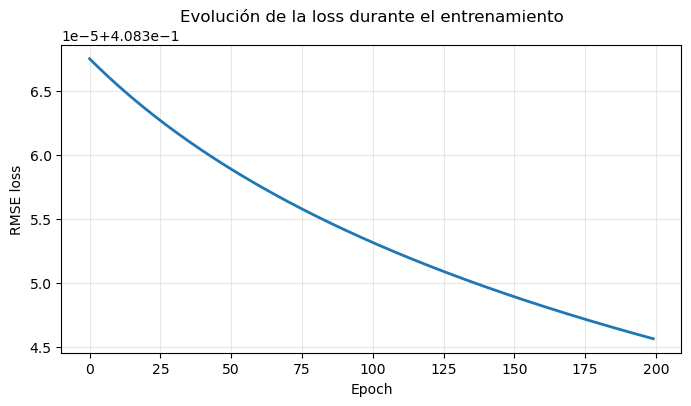

Loss inicial: 0.408368
Loss final  : 0.408346


In [91]:
# ============================================================
# Bloque 19: gráfico de loss
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("RMSE loss")
plt.title("Evolución de la loss durante el entrenamiento")
plt.grid(True, alpha=0.3)

plt.savefig(RESULTS_DIR / "tp2_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Loss inicial: {losses[0]:.6f}")
print(f"Loss final  : {losses[-1]:.6f}")

In [92]:
# ============================================================
# Bloque 20: predicción final de la red entrenada
# ============================================================

activations_trained = forward_network_batch(X, trained_network)
y_pred_trained = activations_trained[-1]

print("Primeras 10 predicciones entrenadas:")
print(y_pred_trained[:10])

Primeras 10 predicciones entrenadas:
[[0.50891786]
 [0.50891789]
 [0.50891793]
 [0.50891796]
 [0.50891799]
 [0.50891803]
 [0.50891806]
 [0.50891809]
 [0.50891813]
 [0.50891816]]


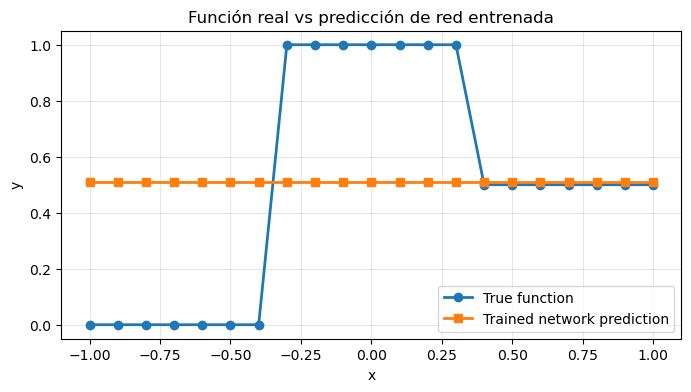

In [93]:
# ============================================================
# Bloque 21: gráfico final de predicción entrenada
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(x_values, y_values, marker="o", linewidth=2, label="True function")
plt.plot(x_values, y_pred_trained.flatten(), marker="s", linewidth=2, label="Trained network prediction")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Función real vs predicción de red entrenada")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(RESULTS_DIR / "tp2_true_vs_trained_prediction.png", dpi=300, bbox_inches="tight")
plt.show()